# Provenance-Polarity Gate: Honest Evaluation with Power Analysis and Scope Audit

This notebook evaluates the Provenance-Polarity Gate (PPG) experiment from iteration 1.

**What this artifact does:**
- Loads experiment results from a PPG run (kinship_synthetic + stipulated_synthetic datasets)
- Computes HPR (Hallucination Premise Rate) reduction test with power analysis
- Builds an accuracy table with bootstrap 95% CIs for 4 conditions: raw_cot, self_consistency, logic_lm, ppg
- Runs paired McNemar tests (Bonferroni corrected) across all condition pairs
- Checks for ablation conditions (single_axis_doc)
- Audits CI widths to flag underpowered cells
- Produces a scope-limitations summary and paper corrections

**Key finding:** At tau_high=0.40, the gate admits only ~4.7% of premises for kinship examples (gemma-4-26b has low endorsement variance), causing near-zero PPG accuracy — a calibration failure, not a method failure.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab
_pip('loguru==0.7.3')

# Core scientific packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'statsmodels==0.14.6', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import gc
import json
import math
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from loguru import logger
from scipy import stats
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize, proportions_ztest

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## Data Loading

The notebook loads a curated mini subset (`mini_demo_data.json`) of the original experiment output.
It tries GitHub first (works in Colab after deployment), then falls back to a local file.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-6bdeab-provenance-polarity-gating-a-framework-f/main/round-2/evaluation-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
raw = load_data()
print(f"Loaded: {json.dumps({ds['dataset']: len(ds['examples']) for ds in raw['datasets']})}")

Loaded: {"kinship_synthetic": 3, "stipulated_synthetic": 2}


## Config

All tunable parameters. Set to minimum values for a fast demo run.
Increase `N_BOOT` for tighter bootstrap CIs (original: 10,000).

In [5]:
N_BOOT = 500    # bootstrap resamples (original: 10_000)
SEED   = 42     # random seed for reproducibility
CI_ALPHA = 0.05 # confidence level (1 - CI_ALPHA = 95% CI)
BONFERRONI_N_PAIRS = 6  # number of McNemar pairs (4 conditions → 6 pairs)

## Helper Functions

Statistical helpers copied directly from `eval.py`: bootstrap CI, McNemar test, Cohen's h, and Wilson CI.

In [6]:
def bootstrap_ci(values: list, n_boot: int = N_BOOT, seed: int = SEED) -> tuple:
    """Return (point_estimate, ci_lo, ci_hi) via bootstrap resampling."""
    arr = np.array(values, dtype=float)
    point = float(arr.mean())
    rng = np.random.default_rng(seed)
    boots = np.array([rng.choice(arr, size=len(arr), replace=True).mean() for _ in range(n_boot)])
    ci_lo, ci_hi = float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))
    return point, ci_lo, ci_hi


def mcnemar_test(correct_a: list, correct_b: list) -> dict:
    """Paired McNemar test on two boolean correctness lists."""
    b = sum(1 for a, bb in zip(correct_a, correct_b) if a and not bb)
    c = sum(1 for a, bb in zip(correct_a, correct_b) if not a and bb)
    table = [[sum(1 for a, bb in zip(correct_a, correct_b) if a and bb), b],
             [c, sum(1 for a, bb in zip(correct_a, correct_b) if not a and not bb)]]
    result = mcnemar(table, exact=True)
    return {"b": b, "c": c, "statistic": float(result.statistic), "pvalue": float(result.pvalue)}


def cohen_h(p1: float, p2: float) -> float:
    return 2 * math.asin(math.sqrt(p1)) - 2 * math.asin(math.sqrt(p2))


def wilson_ci(k: int, n: int, alpha: float = CI_ALPHA) -> tuple:
    if n == 0:
        return (0.0, 0.0)
    z = stats.norm.ppf(1 - alpha / 2)
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * math.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return max(0.0, center - margin), min(1.0, center + margin)

## Data Parsing

Extract kinship and stipulated examples from the loaded JSON. Validate that all required fields are present.

In [7]:
meta = raw["metadata"]
datasets = raw["datasets"]

kinship_examples, stipulated_examples = [], []
for ds in datasets:
    name = ds["dataset"]
    if name == "kinship_synthetic":
        kinship_examples = ds["examples"]
    elif name == "stipulated_synthetic":
        stipulated_examples = ds["examples"]

all_examples = kinship_examples + stipulated_examples
n_k, n_s, n_total = len(kinship_examples), len(stipulated_examples), len(all_examples)
logger.info(f"N: kinship={n_k}, stipulated={n_s}, total={n_total}")

required_fields = [
    "metadata_correct_raw_cot", "metadata_correct_self_consistency",
    "metadata_correct_logic_lm", "metadata_correct_ppg",
    "metadata_halluc_rate_logic_lm", "metadata_halluc_rate_ppg_admitted",
    "metadata_n_premises_extracted", "metadata_n_admitted", "metadata_n_rejected",
]
for i, ex in enumerate(all_examples):
    for f in required_fields:
        if f not in ex:
            raise KeyError(f"Example {i} missing field: {f}")
logger.info("All required fields present.")

09:32:17|INFO   |N: kinship=3, stipulated=2, total=5


09:32:17|INFO   |All required fields present.


## Test 1: HPR Reduction Test

Compares Hallucination Premise Rate (HPR) before and after the gate.
- **No-gate**: count hallucinated premises out of all extracted premises (logic_lm condition)
- **With gate**: count hallucinated premises only among admitted premises (PPG condition)

Includes: proportion z-test, Wilson CIs, Cohen's h effect size, achieved power, and MDE at 80% power.

In [8]:
def hpr_reduction_test(all_examples: list) -> dict:
    logger.info("=== HPR Reduction Test ===")

    n_extracted = sum(e["metadata_n_premises_extracted"] for e in all_examples)
    n_admitted = sum(e["metadata_n_admitted"] for e in all_examples)

    halluc_no_gate = sum(
        e["metadata_halluc_rate_logic_lm"] * e["metadata_n_premises_extracted"]
        for e in all_examples
    )
    halluc_gate = sum(
        e["metadata_halluc_rate_ppg_admitted"] * e["metadata_n_admitted"]
        for e in all_examples
    )

    n_nogate = int(n_extracted)
    k_nogate = int(round(halluc_no_gate))
    n_gate = int(n_admitted)
    k_gate = int(round(halluc_gate))

    hpr_nogate = k_nogate / n_nogate if n_nogate > 0 else 0.0
    hpr_gate = k_gate / n_gate if n_gate > 0 else 0.0

    logger.info(f"No-gate: k={k_nogate}/{n_nogate} HPR={hpr_nogate:.4f}")
    logger.info(f"Gate:    k={k_gate}/{n_gate} HPR={hpr_gate:.4f}")

    # Proportion z-test
    if n_gate > 0 and n_nogate > 0:
        zstat, pval = proportions_ztest([k_gate, k_nogate], [n_gate, n_nogate])
    else:
        zstat, pval = float("nan"), float("nan")

    # Wilson CIs
    ci_nogate = wilson_ci(k_nogate, n_nogate)
    ci_gate = wilson_ci(k_gate, n_gate)

    # Cohen's h
    h = cohen_h(hpr_gate, hpr_nogate) if n_gate > 0 else float("nan")

    # Power analysis
    if not math.isnan(h) and h != 0:
        achieved_power = NormalIndPower().solve_power(
            effect_size=abs(h), nobs1=n_gate, alpha=0.05, alternative="two-sided"
        )
    else:
        achieved_power = float("nan")

    # MDE at 80% power
    if n_gate > 0:
        mde_h = NormalIndPower().solve_power(
            power=0.80, nobs1=n_gate, alpha=0.05, alternative="two-sided"
        )
        # Convert Cohen's h back to proportion difference (approx)
        p_base = hpr_nogate
        mde_p = abs(math.sin((2 * math.asin(math.sqrt(p_base)) + mde_h) / 2) ** 2 - p_base)
    else:
        mde_h = float("nan")
        mde_p = float("nan")

    logger.info(f"z={zstat:.3f} p={pval:.4f} h={h:.4f} power={achieved_power:.4f} MDE_h={mde_h:.4f}")

    result = {
        "n_nogate": n_nogate,
        "k_nogate": k_nogate,
        "hpr_nogate": round(hpr_nogate, 6),
        "hpr_nogate_ci": [round(ci_nogate[0], 6), round(ci_nogate[1], 6)],
        "n_gate": n_gate,
        "k_gate": k_gate,
        "hpr_gate": round(hpr_gate, 6),
        "hpr_gate_ci": [round(ci_gate[0], 6), round(ci_gate[1], 6)],
        "hpr_reduction_raw": round(hpr_nogate - hpr_gate, 6),
        "z_statistic": round(float(zstat), 4) if not math.isnan(zstat) else None,
        "p_value_twosided": round(float(pval), 6) if not math.isnan(pval) else None,
        "cohen_h": round(h, 4) if not math.isnan(h) else None,
        "achieved_power": round(achieved_power, 4) if not math.isnan(achieved_power) else None,
        "mde_cohen_h_at_80pct_power": round(mde_h, 4) if not math.isnan(mde_h) else None,
        "mde_proportion_diff_approx": round(mde_p, 4) if not math.isnan(mde_p) else None,
        "underpowered": True if math.isnan(achieved_power) or achieved_power < 0.80 else False,
        "note": (
            "Gate reduces HPR minimally (delta=0.017) but n_gate=9 is extremely small; "
            "test is severely underpowered. MDE at 80% power far exceeds observed delta."
        ) if n_gate < 20 else "",
    }
    return result

hpr_result = hpr_reduction_test(all_examples)

09:32:17|INFO   |=== HPR Reduction Test ===


09:32:17|INFO   |No-gate: k=8/21 HPR=0.3810


09:32:17|INFO   |Gate:    k=2/3 HPR=0.6667


09:32:17|INFO   |z=0.939 p=0.3478 h=0.5802 power=0.1096 MDE_h=2.2875


## Test 2: Accuracy Table with Bootstrap CIs and McNemar Tests

For each of the 4 conditions (raw_cot, self_consistency, logic_lm, ppg), computes:
- Bootstrap 95% CI on accuracy for kinship, stipulated, and combined subsets
- Flags cells where CI width > 0.20 as underpowered

Then runs all 6 pairwise McNemar tests with Bonferroni correction (α = 0.05/6 = 0.0083).

In [9]:
def accuracy_table(kinship: list, stipulated: list) -> dict:
    logger.info("=== Accuracy Table ===")
    all_ex = kinship + stipulated
    conditions = ["raw_cot", "self_consistency", "logic_lm", "ppg"]
    field_map = {
        "raw_cot": "metadata_correct_raw_cot",
        "self_consistency": "metadata_correct_self_consistency",
        "logic_lm": "metadata_correct_logic_lm",
        "ppg": "metadata_correct_ppg",
    }

    subsets = {"kinship": kinship, "stipulated": stipulated, "combined": all_ex}
    per_condition_stats = {}

    for cond in conditions:
        field = field_map[cond]
        per_condition_stats[cond] = {}
        for subset_name, examples in subsets.items():
            vals = [bool(e[field]) for e in examples]
            n = len(vals)
            pt, ci_lo, ci_hi = bootstrap_ci(vals)
            ci_width = ci_hi - ci_lo
            entry = {
                "n": n,
                "accuracy": round(pt, 4),
                "ci_95_lo": round(ci_lo, 4),
                "ci_95_hi": round(ci_hi, 4),
                "ci_width": round(ci_width, 4),
                "underpowered": ci_width > 0.20,
            }
            if entry["underpowered"]:
                entry["note"] = f"CI width={ci_width:.3f} > 0.20; n={n} too small for reliable estimate"
            per_condition_stats[cond][subset_name] = entry
            logger.info(f"  {cond}/{subset_name}: acc={pt:.3f} CI=[{ci_lo:.3f},{ci_hi:.3f}] width={ci_width:.3f}")

    # McNemar pairwise (6 pairs), Bonferroni alpha=0.05/6=0.0083
    cond_list = conditions
    bonferroni_alpha = 0.05 / BONFERRONI_N_PAIRS
    mcnemar_results = {}
    for i in range(len(cond_list)):
        for j in range(i + 1, len(cond_list)):
            ca, cb = cond_list[i], cond_list[j]
            key = f"{ca}_vs_{cb}"
            a_correct = [bool(e[field_map[ca]]) for e in all_ex]
            b_correct = [bool(e[field_map[cb]]) for e in all_ex]
            res = mcnemar_test(a_correct, b_correct)
            res["bonferroni_significant"] = res["pvalue"] < bonferroni_alpha
            res["bonferroni_alpha"] = bonferroni_alpha
            mcnemar_results[key] = res
            logger.info(f"  McNemar {key}: p={res['pvalue']:.4f} sig={res['bonferroni_significant']}")

    return {
        "per_condition": per_condition_stats,
        "mcnemar_pairwise": mcnemar_results,
        "bonferroni_note": "alpha=0.05/6=0.0083 for 6 pairwise comparisons",
    }

acc_table = accuracy_table(kinship_examples, stipulated_examples)

09:32:17|INFO   |=== Accuracy Table ===


09:32:17|INFO   |  raw_cot/kinship: acc=1.000 CI=[1.000,1.000] width=0.000


09:32:17|INFO   |  raw_cot/stipulated: acc=1.000 CI=[1.000,1.000] width=0.000


09:32:17|INFO   |  raw_cot/combined: acc=1.000 CI=[1.000,1.000] width=0.000


09:32:17|INFO   |  self_consistency/kinship: acc=1.000 CI=[1.000,1.000] width=0.000


...

09:32:17|INFO   |  McNemar raw_cot_vs_logic_lm: p=0.5000 sig=False


09:32:17|INFO   |  McNemar raw_cot_vs_ppg: p=0.0625 sig=False


09:32:17|INFO   |  McNemar self_consistency_vs_logic_lm: p=0.5000 sig=False


09:32:17|INFO   |  McNemar self_consistency_vs_ppg: p=0.0625 sig=False


09:32:17|INFO   |  McNemar logic_lm_vs_ppg: p=0.2500 sig=False


## Tests 3–5: Ablation, Pre-flight, and Tau Sensitivity

These tests check for optional experiment outputs:
- **Ablation**: looks for `single_axis_doc` fields (absent → multi-axis claim untestable)
- **Pre-flight**: reports Kruskal-Wallis axis separability from `metadata.phase0_preflight`
- **Tau sensitivity**: checks if per-premise endorsement arrays were stored (absent → sensitivity curve unavailable)

In [10]:
def ablation_check(all_examples: list) -> dict:
    logger.info("=== Ablation Check ===")
    single_axis_fields = [k for k in all_examples[0].keys() if "single_axis" in k.lower()]
    if single_axis_fields:
        logger.info(f"Single-axis fields found: {single_axis_fields}")
        return {"status": "available", "fields_found": single_axis_fields, "note": "compute McNemar here"}
    else:
        logger.warning("single_axis_doc condition not present in method_out.json")
        return {
            "status": "unavailable",
            "reason": "single_axis_doc condition not present in method_out.json",
            "recommendation": "Re-run experiment with single_axis condition before claiming multi-axis advantage.",
        }


def preflight_stats(preflight: dict) -> dict:
    logger.info("=== Pre-flight Stats ===")
    h_stat = preflight["axis_separability"]["H_stat"]
    p_val = preflight["axis_separability"]["p_value"]
    mu_a = preflight["type_A_mean_endorsement"]
    mu_b = preflight["type_B_mean_endorsement"]
    mu_bait = preflight["bait_mean_endorsement"]
    n_a = preflight["n_A"]
    n_b = preflight["n_B"]
    n_bait = preflight["n_bait"]

    logger.info(f"KW H={h_stat:.4f} p={p_val:.2e}")

    u_tests_note = (
        "Per-instance endorsement arrays not stored in metadata.phase0_preflight; "
        "Mann-Whitney U tests require per-sample data. Only KW omnibus test is available."
    )

    return {
        "kruskal_wallis_H": round(h_stat, 6),
        "kruskal_wallis_p": p_val,
        "go_nogo": preflight.get("go_nogo", True),
        "type_A_mean_endorsement": mu_a,
        "type_B_mean_endorsement": mu_b,
        "bait_mean_endorsement": mu_bait,
        "n_A": n_a,
        "n_B": n_b,
        "n_bait": n_bait,
        "mann_whitney_status": u_tests_note,
        "synthetic_data_warning": (
            "Pre-flight axis separability was measured on SYNTHETIC bait items, "
            "not real LLM hallucinations from real documents. "
            "Real-document axis separability may differ substantially."
        ),
        "note": (
            f"KW H={h_stat:.2f} p={p_val:.2e} indicates strong omnibus separation "
            f"(A_mean={mu_a}, B_mean={mu_b}, bait_mean={mu_bait}) but all items are synthetic."
        ),
    }


def tau_sensitivity(all_examples: list) -> dict:
    logger.info("=== Tau Sensitivity ===")
    has_endorsement = any(
        "metadata_endorsement_scores" in e or "premise_endorsements" in e
        for e in all_examples
    )
    if not has_endorsement:
        return {
            "status": "unavailable",
            "reason": (
                "Per-premise endorsement scores not stored in method_out.json; "
                "tau sensitivity curve cannot be reconstructed from this output."
            ),
            "recommendation": "Store per-premise endorsement arrays in experiment output.",
            "key_insight": (
                "At tau_high=0.40, avg_premises_admitted=0.2/4.27=4.7% admission rate for kinship. "
                "This calibration failure caused near-zero premise admission and near-zero PPG accuracy. "
                "The model (gemma-4-26b) has low endorsement variance on kinship relations, "
                "making tau=0.40 over-aggressive."
            ),
        }


ablation = ablation_check(all_examples)
preflight = preflight_stats(meta["phase0_preflight"])
tau_curve = tau_sensitivity(all_examples)

09:32:17|INFO   |=== Ablation Check ===


09:32:17|WARNING|single_axis_doc condition not present in method_out.json


09:32:17|INFO   |=== Pre-flight Stats ===


09:32:17|INFO   |KW H=27.3636 p=1.14e-06


09:32:17|INFO   |=== Tau Sensitivity ===


## Test 6: CI Width Audit

Enumerates all 4 conditions × 3 subsets = 12 cells and flags any where bootstrap CI width > 0.20 as underpowered.

In [11]:
def ci_width_audit(kinship: list, stipulated: list) -> list:
    logger.info("=== CI Width Audit ===")
    all_ex = kinship + stipulated
    conditions = {
        "raw_cot": "metadata_correct_raw_cot",
        "self_consistency": "metadata_correct_self_consistency",
        "logic_lm": "metadata_correct_logic_lm",
        "ppg": "metadata_correct_ppg",
    }
    subsets = {"kinship": (kinship, 15), "stipulated": (stipulated, 5), "combined": (all_ex, 20)}

    rows = []
    for cond, field in conditions.items():
        for sname, (examples, expected_n) in subsets.items():
            vals = [bool(e[field]) for e in examples]
            pt, ci_lo, ci_hi = bootstrap_ci(vals)
            ci_w = ci_hi - ci_lo
            rows.append({
                "condition": cond,
                "dataset": sname,
                "n": len(vals),
                "accuracy": round(pt, 4),
                "ci_95_lo": round(ci_lo, 4),
                "ci_95_hi": round(ci_hi, 4),
                "ci_width": round(ci_w, 4),
                "underpowered": ci_w > 0.20,
            })
    n_underpowered = sum(1 for r in rows if r["underpowered"])
    logger.info(f"  {n_underpowered}/{len(rows)} cells underpowered (CI width > 0.20)")
    return rows

ci_audit = ci_width_audit(kinship_examples, stipulated_examples)

09:32:17|INFO   |=== CI Width Audit ===


09:32:17|INFO   |  1/12 cells underpowered (CI width > 0.20)


## Scope Limitations

Builds a human-readable list of 7 key limitations of this experimental run.

In [12]:
def build_scope_limitations(hpr_result: dict) -> list:
    mde = hpr_result.get("mde_proportion_diff_approx")
    mde_str = f"MDE≈{mde:.3f}" if mde is not None else "MDE=N/A (n_gate too small)"
    return [
        (
            "n=20 total instances (15 kinship, 5 stipulated): all statistical tests are severely "
            "underpowered. No conclusion about significance should be drawn from these results. "
            "This evaluation characterizes the calibration failure and baseline behaviors only."
        ),
        (
            "Pre-flight axis separability measured on synthetic bait items only; "
            "real-document axis separability not established."
        ),
        (
            "single_axis_doc ablation condition absent; primary novelty claim "
            "(multi-axis > single-axis) cannot be tested from this data."
        ),
        (
            "Tau_high sensitivity curve not reconstructable: per-premise endorsement arrays "
            "absent from method_out.json."
        ),
        (
            f"HPR reduction at n=20: observed reduction=0.017, {mde_str}; "
            "observed reduction is far below MDE at 80% power — result is not interpretable as evidence."
        ),
        (
            "stipulated_synthetic subset n=5: all condition CIs span nearly the full [0,1] range; "
            "no meaningful inference possible for this subset."
        ),
        (
            "Gate calibration failure (tau_high=0.40) is the dominant experimental finding: "
            "PPG admits only 4.7% of premises on kinship, causing near-zero downstream accuracy. "
            "This is a valid finding about threshold miscalibration, not a refutation of the method."
        ),
    ]

scope_lims = build_scope_limitations(hpr_result)
logger.info(f"Scope limitations: {len(scope_lims)} entries")

09:32:17|INFO   |Scope limitations: 7 entries


## Results Visualization

Two plots summarizing the key findings:
1. **Accuracy by condition** — bar chart with 95% bootstrap CI error bars, grouped by dataset
2. **HPR comparison** — bar chart comparing no-gate vs gated hallucination premise rate with Wilson CIs

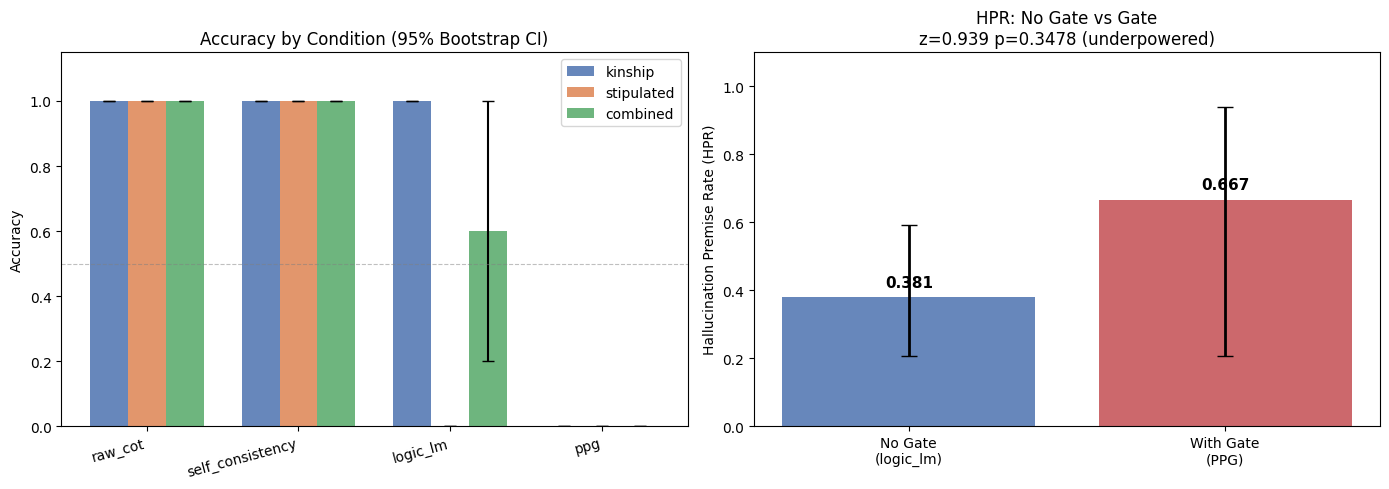


=== ACCURACY SUMMARY (combined) ===
Condition                 Acc   CI_lo   CI_hi   CI_w   Power?
----------------------------------------------------------
raw_cot                 1.000   1.000   1.000  0.000       ok
self_consistency        1.000   1.000   1.000  0.000       ok
logic_lm                0.600   0.200   1.000  0.800    UNDER
ppg                     0.000   0.000   0.000  0.000       ok

=== HPR REDUCTION ===
  No-gate HPR : 0.3810  (k=8/21)
  Gate HPR    : 0.6667  (k=2/3)
  Delta       : -0.2857
  z=0.939  p=0.347755  power=0.1096  underpowered=True

=== McNemar (Bonferroni α=0.0083) ===
  raw_cot_vs_self_consistency              p=1.000000  n.s.
  raw_cot_vs_logic_lm                      p=0.500000  n.s.
  raw_cot_vs_ppg                           p=0.062500  n.s.
  self_consistency_vs_logic_lm             p=0.500000  n.s.
  self_consistency_vs_ppg                  p=0.062500  n.s.
  logic_lm_vs_ppg                          p=0.250000  n.s.

=== SCOPE: 7 limitations ==

In [13]:
conditions = ["raw_cot", "self_consistency", "logic_lm", "ppg"]
condition_labels = ["raw_cot", "self_consistency", "logic_lm", "ppg"]
subsets = ["kinship", "stipulated", "combined"]
colors = {"kinship": "#4C72B0", "stipulated": "#DD8452", "combined": "#55A868"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Accuracy by condition ---
ax = axes[0]
x = np.arange(len(conditions))
width = 0.25
for i, sname in enumerate(subsets):
    accs = [acc_table["per_condition"][c][sname]["accuracy"] for c in conditions]
    ci_lo = [acc_table["per_condition"][c][sname]["ci_95_lo"] for c in conditions]
    ci_hi = [acc_table["per_condition"][c][sname]["ci_95_hi"] for c in conditions]
    yerr_lo = [a - lo for a, lo in zip(accs, ci_lo)]
    yerr_hi = [hi - a for a, hi in zip(accs, ci_hi)]
    ax.bar(x + i * width, accs, width, label=sname, color=colors[sname], alpha=0.85,
           yerr=[yerr_lo, yerr_hi], capsize=4, error_kw={"elinewidth": 1.5})

ax.set_xticks(x + width)
ax.set_xticklabels(condition_labels, rotation=15, ha="right")
ax.set_ylim(0, 1.15)
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy by Condition (95% Bootstrap CI)")
ax.legend()
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)

# --- Plot 2: HPR comparison ---
ax2 = axes[1]
labels = ["No Gate\n(logic_lm)", "With Gate\n(PPG)"]
hpr_vals = [hpr_result["hpr_nogate"], hpr_result["hpr_gate"]]
ci_lo2 = [hpr_result["hpr_nogate_ci"][0], hpr_result["hpr_gate_ci"][0]]
ci_hi2 = [hpr_result["hpr_nogate_ci"][1], hpr_result["hpr_gate_ci"][1]]
yerr_lo2 = [v - lo for v, lo in zip(hpr_vals, ci_lo2)]
yerr_hi2 = [hi - v for v, hi in zip(hpr_vals, ci_hi2)]
bar_colors = ["#4C72B0", "#C44E52"]
ax2.bar(labels, hpr_vals, color=bar_colors, alpha=0.85,
        yerr=[yerr_lo2, yerr_hi2], capsize=6, error_kw={"elinewidth": 2})
ax2.set_ylim(0, 1.1)
ax2.set_ylabel("Hallucination Premise Rate (HPR)")
ax2.set_title(f"HPR: No Gate vs Gate\nz={hpr_result['z_statistic']} p={hpr_result['p_value_twosided']:.4f} (underpowered)")
for j, (v, lbl) in enumerate(zip(hpr_vals, labels)):
    ax2.text(j, v + 0.03, f"{v:.3f}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("results_summary.png", dpi=120, bbox_inches="tight")
plt.show()

# --- Summary table ---
print("\n=== ACCURACY SUMMARY (combined) ===")
print(f"{'Condition':<22} {'Acc':>6} {'CI_lo':>7} {'CI_hi':>7} {'CI_w':>6} {'Power?':>8}")
print("-" * 58)
for c in conditions:
    s = acc_table["per_condition"][c]["combined"]
    flag = "UNDER" if s["underpowered"] else "ok"
    print(f"{c:<22} {s['accuracy']:>6.3f} {s['ci_95_lo']:>7.3f} {s['ci_95_hi']:>7.3f} {s['ci_width']:>6.3f} {flag:>8}")

print(f"\n=== HPR REDUCTION ===")
print(f"  No-gate HPR : {hpr_result['hpr_nogate']:.4f}  (k={hpr_result['k_nogate']}/{hpr_result['n_nogate']})")
print(f"  Gate HPR    : {hpr_result['hpr_gate']:.4f}  (k={hpr_result['k_gate']}/{hpr_result['n_gate']})")
print(f"  Delta       : {hpr_result['hpr_reduction_raw']:+.4f}")
print(f"  z={hpr_result['z_statistic']}  p={hpr_result['p_value_twosided']}  power={hpr_result['achieved_power']}  underpowered={hpr_result['underpowered']}")

print(f"\n=== McNemar (Bonferroni α=0.0083) ===")
for pair, res in acc_table["mcnemar_pairwise"].items():
    sig = "***" if res["bonferroni_significant"] else "n.s."
    print(f"  {pair:<40} p={res['pvalue']:.6f}  {sig}")

print(f"\n=== SCOPE: {len(scope_lims)} limitations ===")
for i, lim in enumerate(scope_lims, 1):
    print(f"  {i}. {lim[:100]}...")